# 🏦 Clasificación de Área por Descripción mediante PLN

**Objetivo**: Entrenar y comparar modelos de Procesamiento del Lenguaje Natural (PLN) para clasificar transacciones bancarias según su **Área** (`Leisure`, `Food`, `Invoice`, `Salary`, `Deposit`, `Investment`, etc.) a partir de la columna **Description** del dataset `db_orig.csv`.

### Contenido del notebook
1. Instalación y configuración del entorno
2. Carga y exploración de datos (EDA)
3. Preprocesamiento de texto
4. División train/test estratificada
5. Definición de pipelines de modelos
6. Entrenamiento con validación cruzada
7. Comparativa de resultados
8. Optimización de hiperparámetros (GridSearchCV)
9. Análisis del mejor modelo (classification report + matriz de confusión)
10. Importancia de características
11. Análisis de errores
12. Inferencia interactiva

---

## 1. Instalación de Dependencias

In [12]:
# Descomenta la siguiente línea si necesitas instalar las librerías
# !pip install pandas numpy scikit-learn matplotlib seaborn

## 2. Importaciones y Configuración

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import re
import time

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    cross_validate,
    StratifiedKFold,
    GridSearchCV,
)
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

SEED = 42
np.random.seed(SEED)
print("✅ Entorno configurado correctamente")

✅ Entorno configurado correctamente


## 3. Carga y Exploración de Datos (EDA)

In [14]:
# Ruta al dataset (ejecución desde el directorio 'playground')
DATA_PATH = os.path.join("..", "data", "raw", "db_orig.csv")

try:
    df_raw = pd.read_csv(DATA_PATH)
    print(f"📊 Dataset cargado exitosamente: {df_raw.shape[0]} filas × {df_raw.shape[1]} columnas")
except FileNotFoundError:
    raise FileNotFoundError(
        f"❌ No se encontró db_orig.csv en '{DATA_PATH}'. "
        "Verifica que ejecutas el notebook desde la carpeta 'playground'."
    )

print(f"\n📋 Columnas disponibles: {df_raw.columns.tolist()}")
print(f"\n📈 Tipos de datos:")
print(df_raw.dtypes)
print(f"\n🔍 Valores nulos por columna:")
print(df_raw.isnull().sum())

df_raw.head()

📊 Dataset cargado exitosamente: 885 filas × 5 columnas

📋 Columnas disponibles: ['Description', 'Date', 'Amount', 'Area', 'Type']

📈 Tipos de datos:
Description    str
Date           str
Amount         str
Area           str
Type           str
dtype: object

🔍 Valores nulos por columna:
Description    0
Date           0
Amount         0
Area           0
Type           0
dtype: int64


,Description,Date,Amount,Area,Type
0,Entretenimiento,28/02/2026,"10,00€",Leisure,Expenses
1,Nómina mensual,27/02/2026,"629,58€",Salary,Income
2,Gasto vacaciones,25/02/2026,"51,00€","Leisure, Vacations",Expenses
3,Pequeño ocio,22/02/2026,"2,80€",Leisure,Expenses
4,Compra alimentación,21/02/2026,"24,80€",Food,Expenses


In [15]:
# Seleccionamos solo Description y Area, eliminamos nulos
df = df_raw[["Description", "Area"]].copy().dropna()
print(f"📋 Dataset limpio: {df.shape[0]} filas")
print(f"🏷️  Clases únicas: {df['Area'].nunique()}")
print(f"\n📊 Distribución de clases:")
print(df["Area"].value_counts().to_string())

📋 Dataset limpio: 885 filas
🏷️  Clases únicas: 9

📊 Distribución de clases:
Area
Invoice               241
Food                  176
Leisure               175
Deposit                89
Salary                 83
Investment             71
Food, Vacations        20
Leisure, Vacations     17
Invoice, Vacations     13


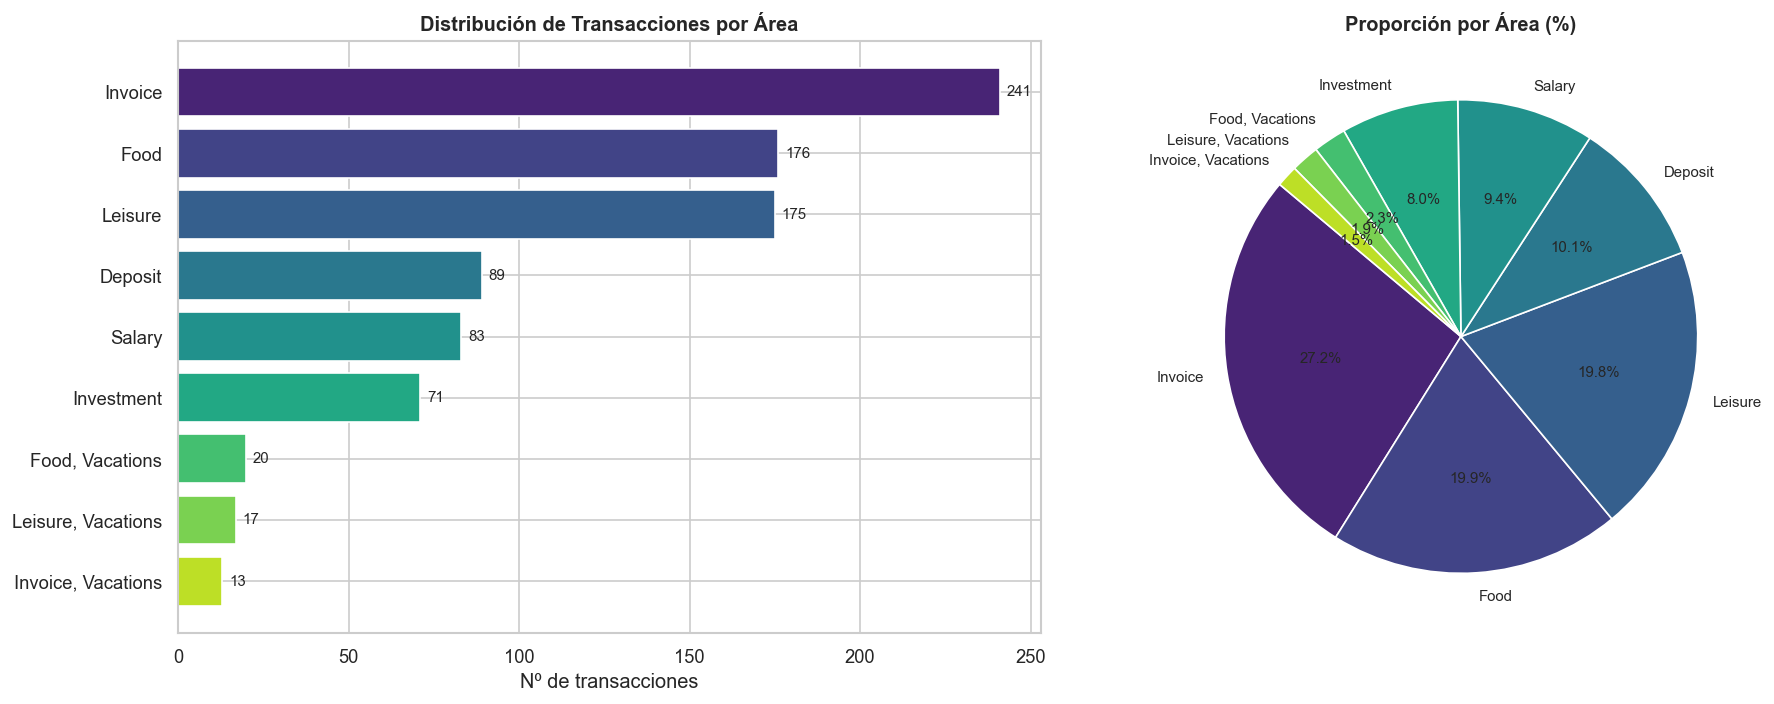

In [16]:
# --- Visualización: Distribución de clases ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de barras
area_counts = df["Area"].value_counts()
colors = sns.color_palette("viridis", len(area_counts))
axes[0].barh(area_counts.index[::-1], area_counts.values[::-1], color=colors[::-1])
axes[0].set_xlabel("Nº de transacciones")
axes[0].set_title("Distribución de Transacciones por Área", fontweight="bold")
for i, (count, name) in enumerate(zip(area_counts.values[::-1], area_counts.index[::-1])):
    axes[0].text(count + 2, i, str(count), va='center', fontsize=9)

# Gráfico de tarta
axes[1].pie(
    area_counts.values,
    labels=area_counts.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=140,
    textprops={"fontsize": 9},
)
axes[1].set_title("Proporción por Área (%)", fontweight="bold")

plt.tight_layout()
plt.show()

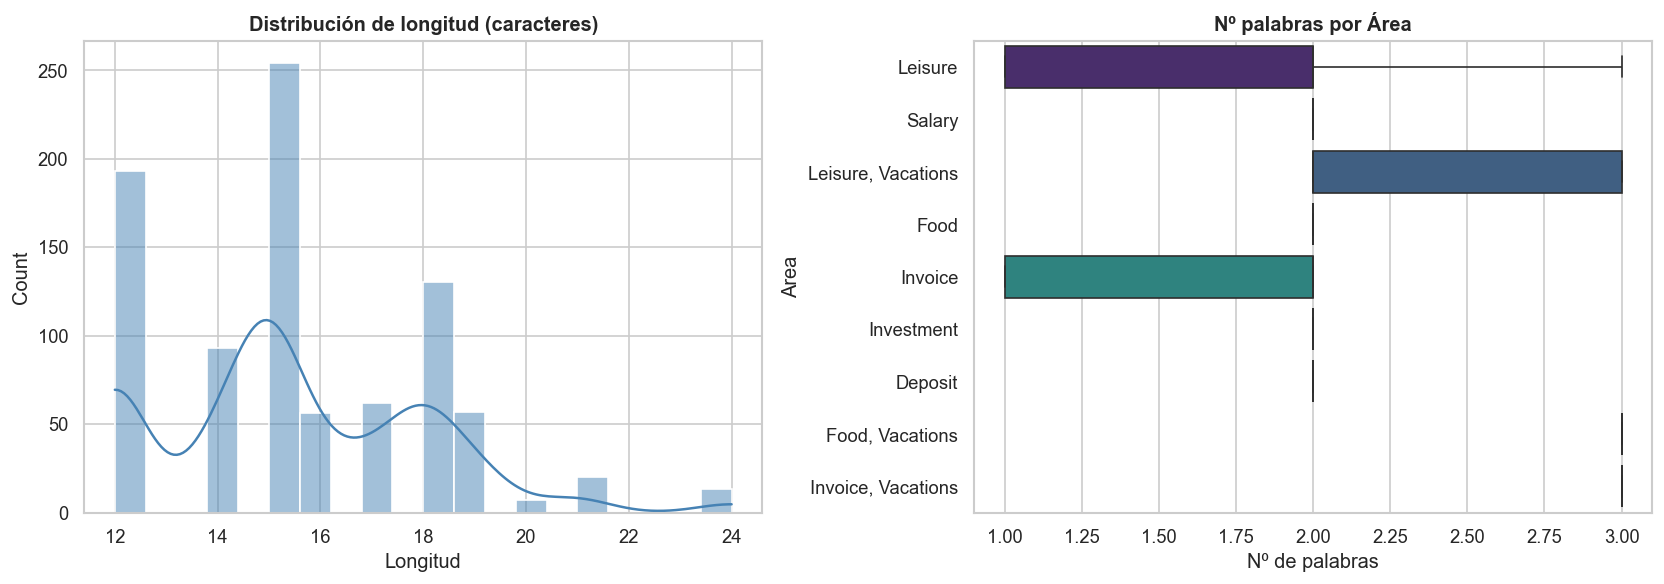


📏 Estadísticas de longitud de descripción (caracteres):
count    885.000000
mean      15.449718
std        2.601995
min       12.000000
25%       14.000000
50%       15.000000
75%       18.000000
max       24.000000


In [17]:
# --- Estadísticas de las descripciones ---
df["desc_len"] = df["Description"].str.len()
df["desc_words"] = df["Description"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["desc_len"], bins=20, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribución de longitud (caracteres)", fontweight="bold")
axes[0].set_xlabel("Longitud")

sns.boxplot(data=df, x="desc_words", y="Area", orient="h", ax=axes[1], palette="viridis")
axes[1].set_title("Nº palabras por Área", fontweight="bold")
axes[1].set_xlabel("Nº de palabras")

plt.tight_layout()
plt.show()

print("\n📏 Estadísticas de longitud de descripción (caracteres):")
print(df["desc_len"].describe().to_string())

# Limpiamos las columnas auxiliares
df.drop(columns=["desc_len", "desc_words"], inplace=True)

## 4. Preprocesamiento de Texto

Aplicamos una limpieza ligera: minúsculas, eliminación de caracteres especiales y normalización de espacios. Las descripciones son cortas (~15 caracteres) así que no aplicamos stemming/lemmatización para no perder información.

In [18]:
def preprocess_text(text: str) -> str:
    """Limpieza básica de texto."""
    text = text.lower().strip()
    text = re.sub(r"[^a-záéíóúüñ\s]", "", text)   # solo letras y espacios
    text = re.sub(r"\s+", " ", text).strip()        # normalizar espacios
    return text

df["Description_clean"] = df["Description"].apply(preprocess_text)

# Muestra de antes/después
print("🔧 Ejemplo de preprocesamiento:")
sample = df[["Description", "Description_clean", "Area"]].sample(5, random_state=SEED)
display(sample)

🔧 Ejemplo de preprocesamiento:


,Description,Description_clean,Area
44,Pequeño ingreso,pequeño ingreso,Deposit
388,Microfactura,microfactura,Invoice
703,"Gasto food, vacations",gasto food vacations,"Food, Vacations"
643,Nómina mensual,nómina mensual,Salary
880,Entretenimiento,entretenimiento,Leisure


## 5. División Train / Test (80/20 estratificada)

In [19]:
X = df["Description_clean"]
y = df["Area"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f"🔀 Split completado:")
print(f"   Train: {len(X_train)} muestras")
print(f"   Test:  {len(X_test)} muestras")
print(f"\n📊 Distribución en train:")
print(y_train.value_counts().to_string())

🔀 Split completado:
   Train: 708 muestras
   Test:  177 muestras

📊 Distribución en train:
Area
Invoice               193
Food                  141
Leisure               140
Deposit                71
Salary                 66
Investment             57
Food, Vacations        16
Leisure, Vacations     14
Invoice, Vacations     10


## 6. Definición de Pipelines de Modelos

Definimos 6 modelos con distintas estrategias de vectorización y clasificación:

| Modelo | Vectorización | Clasificador |
|--------|--------------|---------------|
| Naive Bayes (BoW) | CountVectorizer (uni+bigrams) | MultinomialNB |
| Complement NB | TF-IDF | ComplementNB |
| Logistic Regression | TF-IDF (sublinear) | LogisticRegression |
| SVM Lineal | TF-IDF (sublinear) | LinearSVC |
| Random Forest | TF-IDF | RandomForestClassifier |
| HistGradientBoosting | TF-IDF → dense | HistGradientBoostingClassifier |

In [20]:
def create_pipelines():
    """Crea un diccionario con los pipelines de cada modelo."""
    return {
        "Naive Bayes (BoW)": Pipeline([
            ("vec", CountVectorizer(
                ngram_range=(1, 2), max_features=5000,
                strip_accents="unicode", analyzer="word"
            )),
            ("clf", MultinomialNB(alpha=0.1))
        ]),
        "Complement NB": Pipeline([
            ("vec", TfidfVectorizer(
                ngram_range=(1, 2), max_features=5000,
                strip_accents="unicode", sublinear_tf=True
            )),
            ("clf", ComplementNB(alpha=0.5))
        ]),
        "Logistic Regression": Pipeline([
            ("vec", TfidfVectorizer(
                ngram_range=(1, 2), max_features=5000,
                sublinear_tf=True, strip_accents="unicode"
            )),
            ("clf", LogisticRegression(
                max_iter=1000, C=1.0, solver="lbfgs", random_state=SEED
            ))
        ]),
        "SVM Lineal": Pipeline([
            ("vec", TfidfVectorizer(
                ngram_range=(1, 2), max_features=5000,
                sublinear_tf=True, strip_accents="unicode"
            )),
            ("clf", LinearSVC(max_iter=2000, random_state=SEED))
        ]),
        "Random Forest": Pipeline([
            ("vec", TfidfVectorizer(
                ngram_range=(1, 2), max_features=5000,
                strip_accents="unicode"
            )),
            ("clf", RandomForestClassifier(
                n_estimators=200, random_state=SEED, n_jobs=-1
            ))
        ]),
        "HistGradientBoosting": Pipeline([
            ("vec", TfidfVectorizer(
                ngram_range=(1, 2), max_features=5000,
                strip_accents="unicode"
            )),
            ("to_dense", FunctionTransformer(
                lambda x: x.toarray(), accept_sparse=True
            )),
            ("clf", HistGradientBoostingClassifier(
                max_iter=300, learning_rate=0.1, random_state=SEED
            ))
        ]),
    }

pipelines = create_pipelines()
print(f"🤖 {len(pipelines)} pipelines creados:")
for name in pipelines:
    print(f"   • {name}")

🤖 6 pipelines creados:
   • Naive Bayes (BoW)
   • Complement NB
   • Logistic Regression
   • SVM Lineal
   • Random Forest
   • HistGradientBoosting


## 7. Entrenamiento y Evaluación con Validación Cruzada (5-Fold)

In [21]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

scoring = {
    "accuracy": "accuracy",
    "f1_weighted": "f1_weighted",
    "precision_weighted": "precision_weighted",
    "recall_weighted": "recall_weighted",
}

results = []

for name, pipe in pipelines.items():
    print(f"🔄 Entrenando {name}...", end=" ")
    t0 = time.time()

    # Validación cruzada con múltiples métricas
    cv_results = cross_validate(
        pipe, X_train, y_train, cv=cv, scoring=scoring, return_train_score=False
    )

    # Ajuste final en todo el train y predicción en test
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    elapsed = time.time() - t0

    results.append({
        "Modelo": name,
        "CV Acc (media ± std)": f"{cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}",
        "CV Acc (media)": cv_results["test_accuracy"].mean(),
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Test F1 (weighted)": f1_score(y_test, y_pred, average="weighted"),
        "Test Precision (w)": precision_score(y_test, y_pred, average="weighted"),
        "Test Recall (w)": recall_score(y_test, y_pred, average="weighted"),
        "Tiempo (s)": round(elapsed, 2),
    })
    print(f"✅ ({elapsed:.1f}s) — Test Acc: {results[-1]['Test Accuracy']:.4f}")

print("\n🎯 Entrenamiento completado.")

🔄 Entrenando Naive Bayes (BoW)... ✅ (0.3s) — Test Acc: 1.0000
🔄 Entrenando Complement NB... ✅ (0.2s) — Test Acc: 1.0000
🔄 Entrenando Logistic Regression... ✅ (0.3s) — Test Acc: 1.0000
🔄 Entrenando SVM Lineal... ✅ (0.3s) — Test Acc: 1.0000
🔄 Entrenando Random Forest... ✅ (5.1s) — Test Acc: 1.0000
🔄 Entrenando HistGradientBoosting... ✅ (11.2s) — Test Acc: 1.0000

🎯 Entrenamiento completado.


## 8. Comparativa de Resultados

In [22]:
df_results = pd.DataFrame(results).sort_values("Test Accuracy", ascending=False)

# Tabla con resaltado
display(
    df_results[
        ["Modelo", "CV Acc (media ± std)", "Test Accuracy",
         "Test F1 (weighted)", "Test Precision (w)", "Test Recall (w)", "Tiempo (s)"]
    ].style
    .highlight_max(subset=["Test Accuracy", "Test F1 (weighted)"], color="lightgreen")
    .highlight_min(subset=["Tiempo (s)"], color="lightyellow")
    .format({
        "Test Accuracy": "{:.4f}",
        "Test F1 (weighted)": "{:.4f}",
        "Test Precision (w)": "{:.4f}",
        "Test Recall (w)": "{:.4f}",
    })
    .set_caption("📊 Comparativa de Modelos de PLN")
)

,Modelo,CV Acc (media ± std),Test Accuracy,Test F1 (weighted),Test Precision (w),Test Recall (w),Tiempo (s)
0,Naive Bayes (BoW),0.9958 ± 0.0085,1.0000,1.0000,1.0000,1.0000,0.260000
1,Complement NB,1.0000 ± 0.0000,1.0000,1.0000,1.0000,1.0000,0.210000
2,Logistic Regression,1.0000 ± 0.0000,1.0000,1.0000,1.0000,1.0000,0.310000
3,SVM Lineal,1.0000 ± 0.0000,1.0000,1.0000,1.0000,1.0000,0.310000
4,Random Forest,1.0000 ± 0.0000,1.0000,1.0000,1.0000,1.0000,5.120000
5,HistGradientBoosting,1.0000 ± 0.0000,1.0000,1.0000,1.0000,1.0000,11.170000


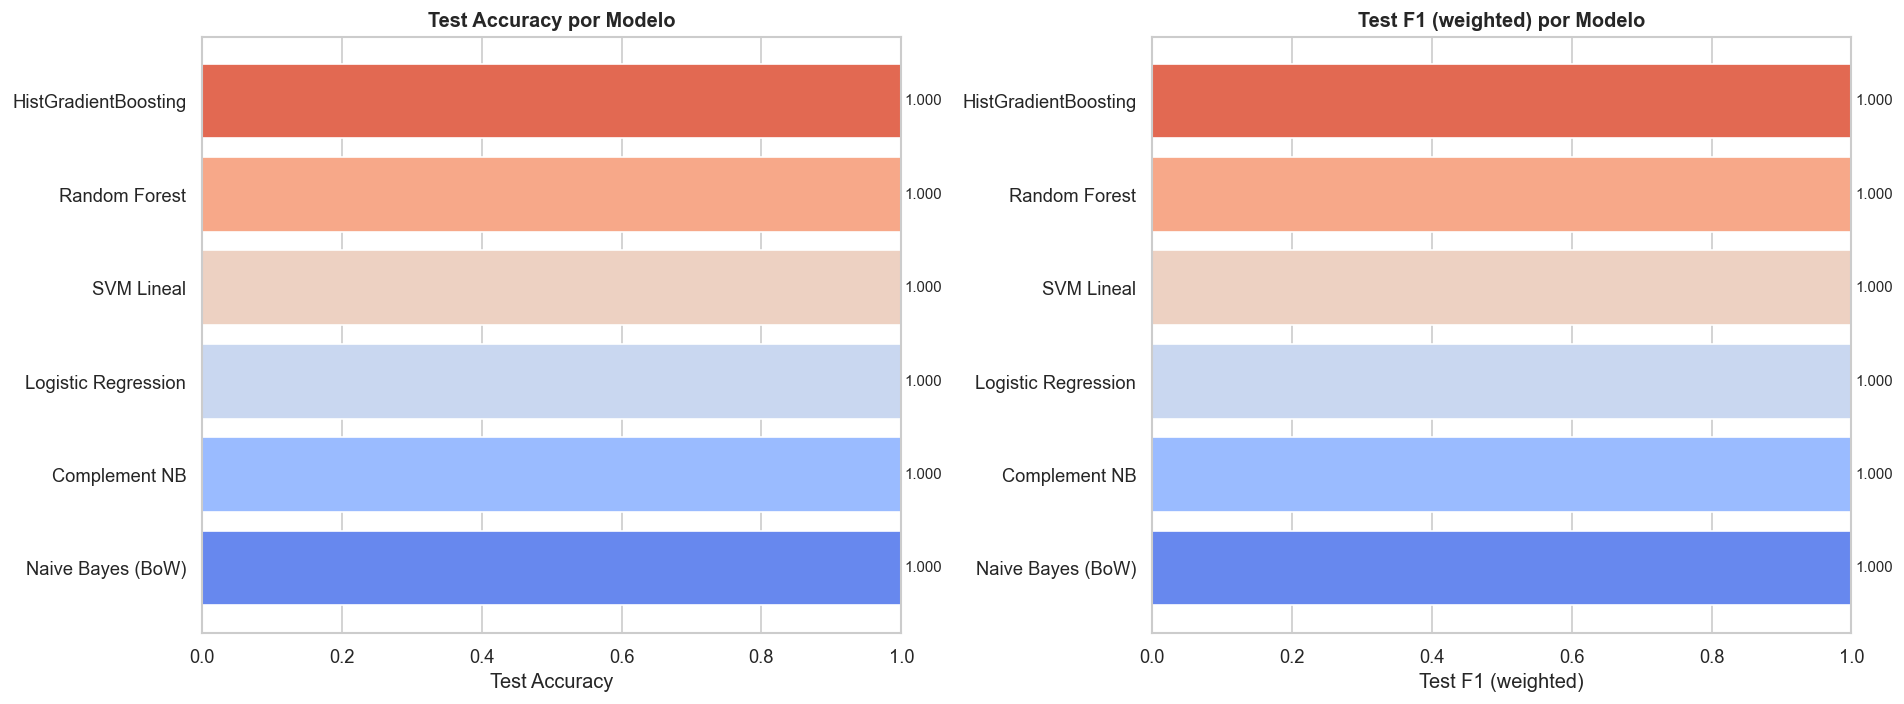

💾 Gráfico guardado en 'resultados_comparativa.png'


In [23]:
# --- Gráfico comparativo ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

models_sorted = df_results.sort_values("Test Accuracy")
colors_bar = sns.color_palette("coolwarm", len(models_sorted))

# Accuracy
axes[0].barh(models_sorted["Modelo"], models_sorted["Test Accuracy"], color=colors_bar)
axes[0].set_xlabel("Test Accuracy")
axes[0].set_title("Test Accuracy por Modelo", fontweight="bold")
axes[0].set_xlim(0, 1)
for i, (acc, name) in enumerate(zip(models_sorted["Test Accuracy"], models_sorted["Modelo"])):
    axes[0].text(acc + 0.005, i, f"{acc:.3f}", va="center", fontsize=9)

# F1 (weighted)
axes[1].barh(models_sorted["Modelo"], models_sorted["Test F1 (weighted)"], color=colors_bar)
axes[1].set_xlabel("Test F1 (weighted)")
axes[1].set_title("Test F1 (weighted) por Modelo", fontweight="bold")
axes[1].set_xlim(0, 1)
for i, (f1, name) in enumerate(zip(models_sorted["Test F1 (weighted)"], models_sorted["Modelo"])):
    axes[1].text(f1 + 0.005, i, f"{f1:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("resultados_comparativa.png", bbox_inches="tight")
plt.show()
print("💾 Gráfico guardado en 'resultados_comparativa.png'")

## 9. Optimización de Hiperparámetros (GridSearchCV)

Optimizamos el mejor modelo (o Logistic Regression como buen candidato) con una búsqueda de hiperparámetros para intentar mejorar el rendimiento.

In [24]:
# Optimizamos Logistic Regression con distintas configuraciones de TF-IDF
param_grid = {
    "vec__ngram_range": [(1, 1), (1, 2), (1, 3)],
    "vec__max_features": [3000, 5000, 8000],
    "vec__sublinear_tf": [True, False],
    "clf__C": [0.1, 0.5, 1.0, 5.0, 10.0],
}

lr_pipe = Pipeline([
    ("vec", TfidfVectorizer(strip_accents="unicode")),
    ("clf", LogisticRegression(max_iter=1000, solver="lbfgs", random_state=SEED)),
])

grid_search = GridSearchCV(
    lr_pipe, param_grid, cv=cv,
    scoring="f1_weighted", n_jobs=-1, verbose=1, refit=True
)

print("🔍 Ejecutando GridSearchCV...")
grid_search.fit(X_train, y_train)

print(f"\n🏆 Mejores hiperparámetros:")
for param, val in grid_search.best_params_.items():
    print(f"   • {param}: {val}")

print(f"\n📈 Mejor F1 (weighted) en CV: {grid_search.best_score_:.4f}")

# Evaluamos en test
y_pred_tuned = grid_search.predict(X_test)
print(f"📊 Test Accuracy (tuned): {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"📊 Test F1 weighted (tuned): {f1_score(y_test, y_pred_tuned, average='weighted'):.4f}")

🔍 Ejecutando GridSearchCV...
Fitting 5 folds for each of 90 candidates, totalling 450 fits

🏆 Mejores hiperparámetros:
   • clf__C: 0.5
   • vec__max_features: 3000
   • vec__ngram_range: (1, 1)
   • vec__sublinear_tf: True

📈 Mejor F1 (weighted) en CV: 1.0000
📊 Test Accuracy (tuned): 1.0000
📊 Test F1 weighted (tuned): 1.0000


## 10. Análisis del Mejor Modelo

In [25]:
# Selección del mejor modelo (comparamos el baseline vs tuned)
best_baseline_name = df_results.iloc[0]["Modelo"]
best_baseline_acc = df_results.iloc[0]["Test Accuracy"]
tuned_acc = accuracy_score(y_test, y_pred_tuned)

if tuned_acc >= best_baseline_acc:
    best_model = grid_search.best_estimator_
    best_name = "LR (Tuned — GridSearchCV)"
    y_pred_best = y_pred_tuned
    print(f"🏆 El modelo optimizado supera al mejor baseline:")
    print(f"   LR Tuned: {tuned_acc:.4f} vs {best_baseline_name}: {best_baseline_acc:.4f}")
else:
    best_model = pipelines[best_baseline_name]
    best_name = best_baseline_name
    y_pred_best = best_model.predict(X_test)
    print(f"🏆 El mejor baseline sigue siendo superior:")
    print(f"   {best_baseline_name}: {best_baseline_acc:.4f} vs LR Tuned: {tuned_acc:.4f}")

print(f"\n{'═' * 60}")
print(f"📋 Classification Report — {best_name}")
print(f"{'═' * 60}")
print(classification_report(y_test, y_pred_best, digits=4))

🏆 El modelo optimizado supera al mejor baseline:
   LR Tuned: 1.0000 vs Naive Bayes (BoW): 1.0000

════════════════════════════════════════════════════════════
📋 Classification Report — LR (Tuned — GridSearchCV)
════════════════════════════════════════════════════════════
                    precision    recall  f1-score   support

           Deposit     1.0000    1.0000    1.0000        18
              Food     1.0000    1.0000    1.0000        35
   Food, Vacations     1.0000    1.0000    1.0000         4
        Investment     1.0000    1.0000    1.0000        14
           Invoice     1.0000    1.0000    1.0000        48
Invoice, Vacations     1.0000    1.0000    1.0000         3
           Leisure     1.0000    1.0000    1.0000        35
Leisure, Vacations     1.0000    1.0000    1.0000         3
            Salary     1.0000    1.0000    1.0000        17

          accuracy                         1.0000       177
         macro avg     1.0000    1.0000    1.0000       177
     

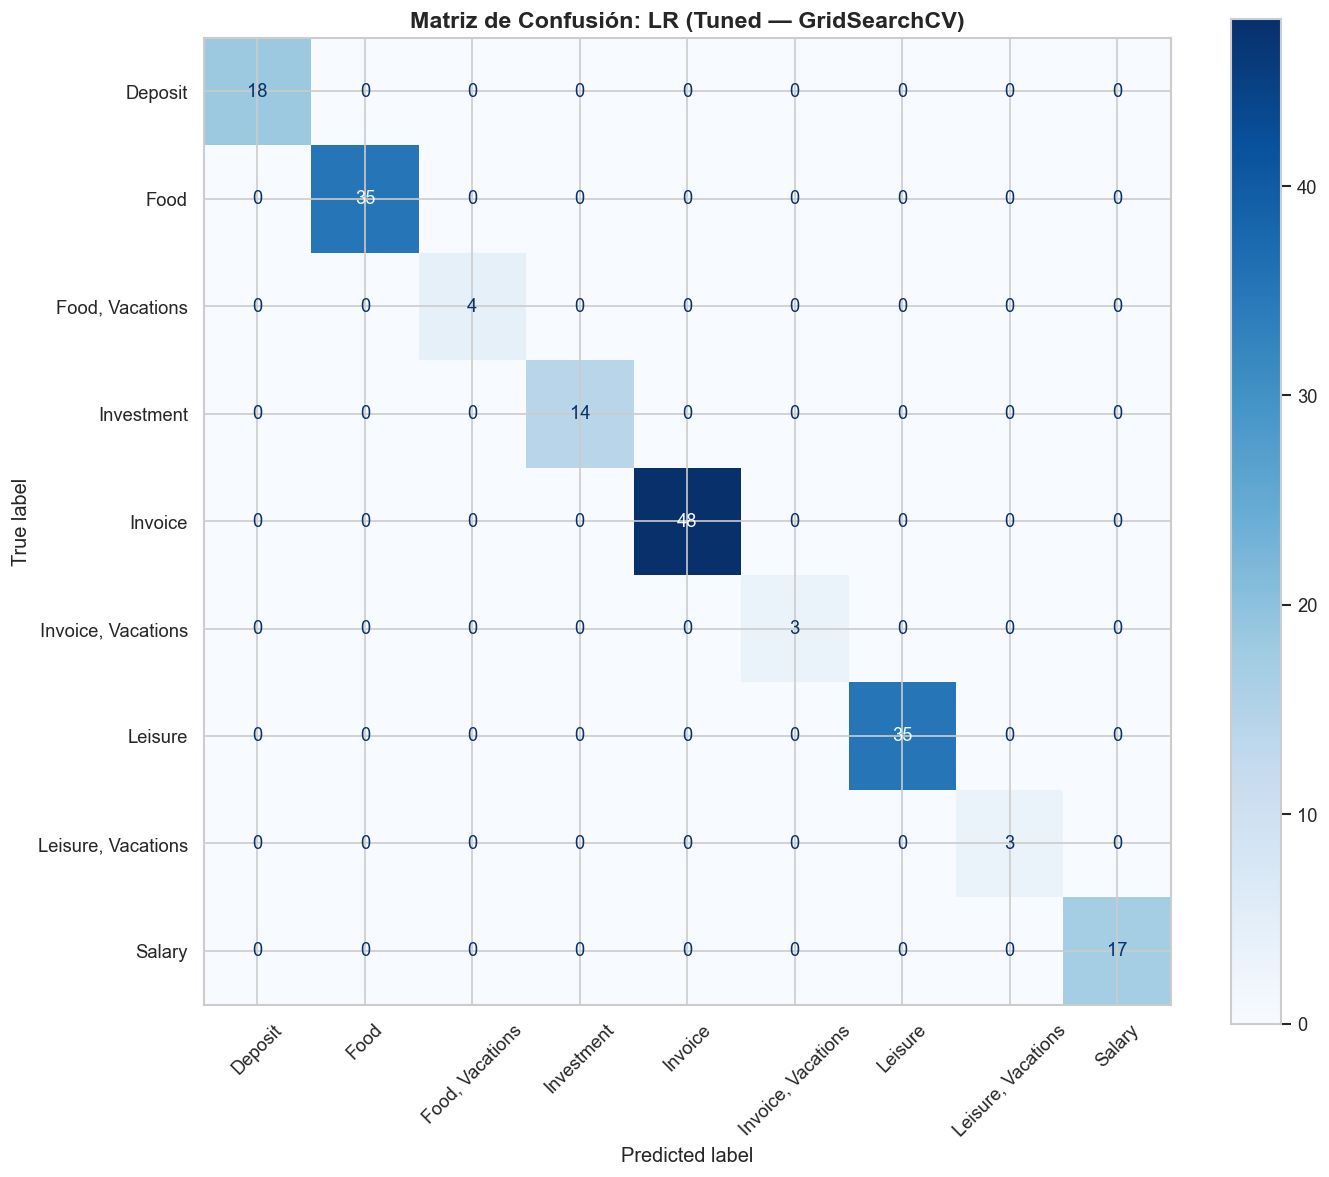

💾 Matriz guardada en 'matrices_confusion.png'


In [26]:
# --- Matriz de Confusión del mejor modelo ---
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best, ax=ax, cmap="Blues",
    xticks_rotation=45, values_format="d"
)
ax.set_title(f"Matriz de Confusión: {best_name}", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig("matrices_confusion.png", bbox_inches="tight")
plt.show()
print("💾 Matriz guardada en 'matrices_confusion.png'")

## 11. Importancia de Palabras (Top Features por Clase)

Analizamos los coeficientes del modelo Logistic Regression para ver qué palabras son más discriminativas para cada categoría.

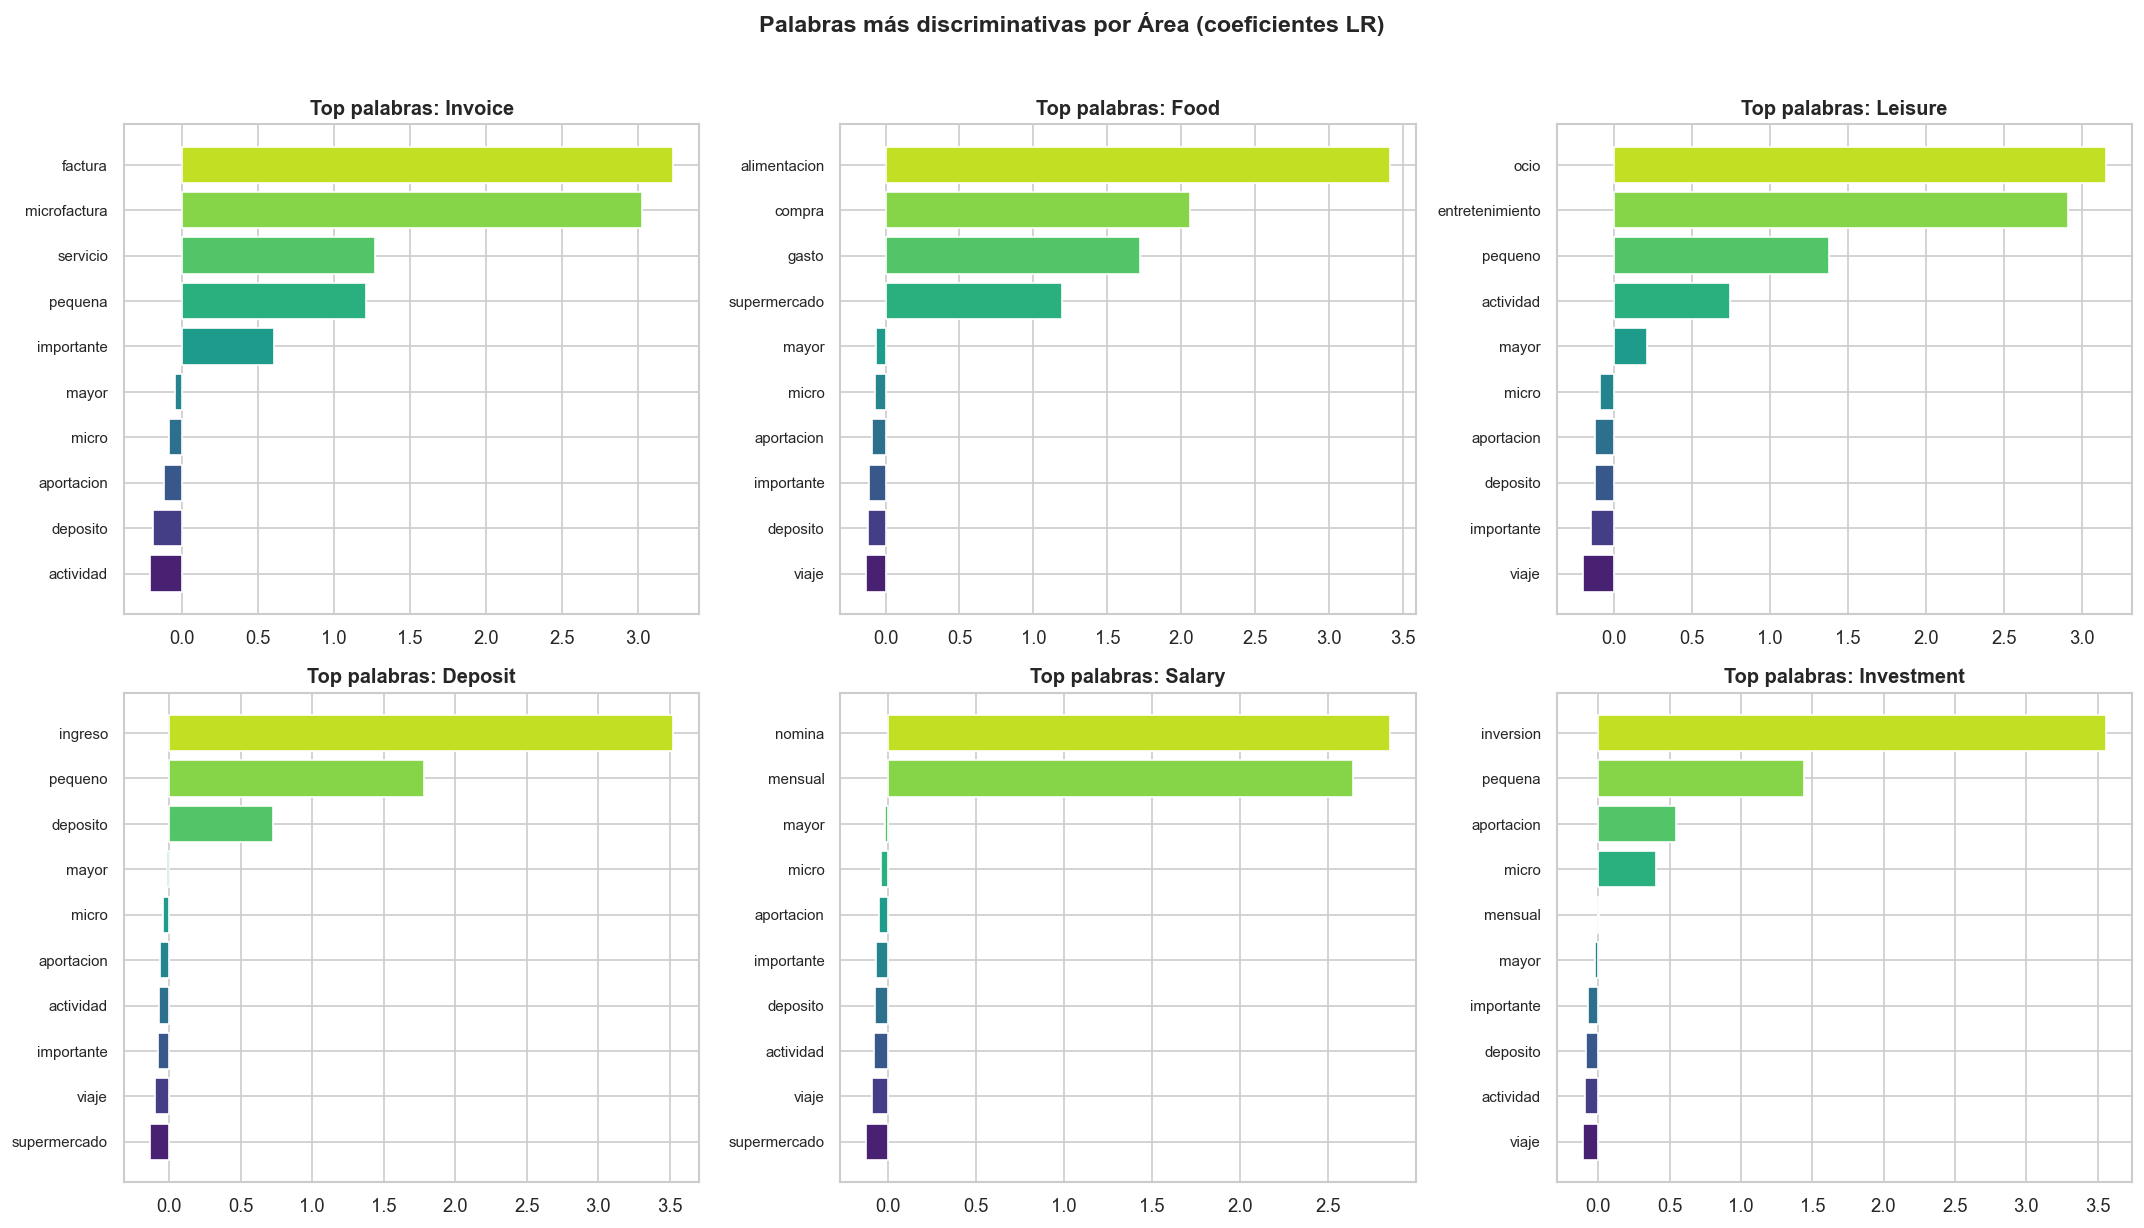

💾 Gráfico guardado en 'importancia_palabras.png'


In [27]:
# Usamos el pipeline LR (tuned o baseline) para el análisis de coeficientes
if hasattr(best_model, 'named_steps') and hasattr(best_model.named_steps.get('clf', None), 'coef_'):
    lr_analysis = best_model
else:
    lr_analysis = pipelines["Logistic Regression"]

vec = lr_analysis.named_steps["vec"]
clf = lr_analysis.named_steps["clf"]
features = vec.get_feature_names_out()
classes = clf.classes_

# Tomamos las top N áreas más frecuentes
n_areas = min(len(classes), 6)
top_areas = df["Area"].value_counts().head(n_areas).index

n_cols = 3
n_rows = (n_areas + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = axes.flatten()

for i, area in enumerate(top_areas):
    area_idx = list(classes).index(area)
    coefs = clf.coef_[area_idx]
    top_idx = np.argsort(coefs)[-10:]

    axes[i].barh(features[top_idx], coefs[top_idx], color=sns.color_palette("viridis", 10))
    axes[i].set_title(f"Top palabras: {area}", fontweight="bold")
    axes[i].tick_params(axis="y", labelsize=9)

# Ocultar ejes sobrantes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Palabras más discriminativas por Área (coeficientes LR)",
             fontweight="bold", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("importancia_palabras.png", bbox_inches="tight")
plt.show()
print("💾 Gráfico guardado en 'importancia_palabras.png'")

## 12. Análisis de Errores

Revisamos las muestras que el modelo clasifica incorrectamente para entender sus debilidades.

In [28]:
# Construir DataFrame con predicciones
df_eval = pd.DataFrame({
    "Description": X_test.values,
    "Real": y_test.values,
    "Predicho": y_pred_best,
})
df_eval["Correcto"] = df_eval["Real"] == df_eval["Predicho"]

n_errors = (~df_eval["Correcto"]).sum()
n_total = len(df_eval)
print(f"❌ Errores: {n_errors} / {n_total} ({n_errors/n_total*100:.1f}%)")
print(f"✅ Aciertos: {n_total - n_errors} / {n_total} ({(n_total - n_errors)/n_total*100:.1f}%)")

errors = df_eval[~df_eval["Correcto"]].copy()
if len(errors) > 0:
    print(f"\n📋 Todas las predicciones erróneas ({len(errors)}):")
    display(errors.sort_values(["Real", "Predicho"]))

    # Resumen de confusiones más comunes
    print("\n🔄 Confusiones más frecuentes:")
    confusion_pairs = errors.groupby(["Real", "Predicho"]).size().sort_values(ascending=False)
    display(confusion_pairs.head(10))
else:
    print("\n🎉 ¡El modelo no cometió ningún error en test!")

❌ Errores: 0 / 177 (0.0%)
✅ Aciertos: 177 / 177 (100.0%)

🎉 ¡El modelo no cometió ningún error en test!


## 13. Ensamble: Voting Classifier

Combinamos los mejores modelos individuales en un **VotingClassifier** para ver si mejoramos el rendimiento.

In [29]:
# Recreamos los pipelines para el voting (necesitan ser nuevas instancias)
voting_estimators = [
    ("lr", Pipeline([
        ("vec", TfidfVectorizer(ngram_range=(1, 2), max_features=5000,
                                sublinear_tf=True, strip_accents="unicode")),
        ("clf", LogisticRegression(max_iter=1000, random_state=SEED))
    ])),
    ("svm", Pipeline([
        ("vec", TfidfVectorizer(ngram_range=(1, 2), max_features=5000,
                                sublinear_tf=True, strip_accents="unicode")),
        ("clf", LinearSVC(max_iter=2000, random_state=SEED))
    ])),
    ("nb", Pipeline([
        ("vec", CountVectorizer(ngram_range=(1, 2), max_features=5000,
                                strip_accents="unicode")),
        ("clf", MultinomialNB(alpha=0.1))
    ])),
]

voting = VotingClassifier(estimators=voting_estimators, voting="hard")

print("🗳️ Entrenando VotingClassifier (LR + SVM + NB)...")
voting.fit(X_train, y_train)
y_pred_voting = voting.predict(X_test)

voting_acc = accuracy_score(y_test, y_pred_voting)
voting_f1 = f1_score(y_test, y_pred_voting, average="weighted")

print(f"\n📊 Voting Classifier:")
print(f"   Test Accuracy:     {voting_acc:.4f}")
print(f"   Test F1 (weighted): {voting_f1:.4f}")
print(f"\n🏆 Comparación con el mejor individual ({best_name}):")
print(f"   Individual — Acc: {accuracy_score(y_test, y_pred_best):.4f}")
print(f"   Voting     — Acc: {voting_acc:.4f}")

if voting_acc > accuracy_score(y_test, y_pred_best):
    print("   ✅ El ensamble mejora el rendimiento.")
else:
    print("   ℹ️ El modelo individual sigue siendo igual o mejor.")

🗳️ Entrenando VotingClassifier (LR + SVM + NB)...

📊 Voting Classifier:
   Test Accuracy:     1.0000
   Test F1 (weighted): 1.0000

🏆 Comparación con el mejor individual (LR (Tuned — GridSearchCV)):
   Individual — Acc: 1.0000
   Voting     — Acc: 1.0000
   ℹ️ El modelo individual sigue siendo igual o mejor.


## 14. Resumen Final y Conclusiones

In [30]:
# Añadimos Voting y LR Tuned al resumen
all_results = results.copy()
all_results.append({
    "Modelo": "LR (Tuned)",
    "CV Acc (media ± std)": "-",
    "CV Acc (media)": 0,
    "Test Accuracy": accuracy_score(y_test, y_pred_tuned),
    "Test F1 (weighted)": f1_score(y_test, y_pred_tuned, average="weighted"),
    "Test Precision (w)": precision_score(y_test, y_pred_tuned, average="weighted"),
    "Test Recall (w)": recall_score(y_test, y_pred_tuned, average="weighted"),
    "Tiempo (s)": "-",
})
all_results.append({
    "Modelo": "Voting (LR+SVM+NB)",
    "CV Acc (media ± std)": "-",
    "CV Acc (media)": 0,
    "Test Accuracy": voting_acc,
    "Test F1 (weighted)": voting_f1,
    "Test Precision (w)": precision_score(y_test, y_pred_voting, average="weighted"),
    "Test Recall (w)": recall_score(y_test, y_pred_voting, average="weighted"),
    "Tiempo (s)": "-",
})

df_final = pd.DataFrame(all_results).sort_values("Test Accuracy", ascending=False)

print("\n" + "=" * 70)
print("   📊 RESUMEN FINAL: Clasificación de Área por Descripción (PLN)")
print("=" * 70)
display(
    df_final[
        ["Modelo", "Test Accuracy", "Test F1 (weighted)", "Test Precision (w)", "Test Recall (w)"]
    ].style
    .highlight_max(subset=["Test Accuracy", "Test F1 (weighted)"], color="lightgreen")
    .format({
        "Test Accuracy": "{:.4f}",
        "Test F1 (weighted)": "{:.4f}",
        "Test Precision (w)": "{:.4f}",
        "Test Recall (w)": "{:.4f}",
    })
)

winner = df_final.iloc[0]
print(f"\n🏆 Mejor modelo: {winner['Modelo']}")
print(f"   Test Accuracy:     {winner['Test Accuracy']:.4f}")
print(f"   Test F1 (weighted): {winner['Test F1 (weighted)']:.4f}")


   📊 RESUMEN FINAL: Clasificación de Área por Descripción (PLN)


,Modelo,Test Accuracy,Test F1 (weighted),Test Precision (w),Test Recall (w)
0,Naive Bayes (BoW),1.0000,1.0000,1.0000,1.0000
1,Complement NB,1.0000,1.0000,1.0000,1.0000
2,Logistic Regression,1.0000,1.0000,1.0000,1.0000
3,SVM Lineal,1.0000,1.0000,1.0000,1.0000
4,Random Forest,1.0000,1.0000,1.0000,1.0000
5,HistGradientBoosting,1.0000,1.0000,1.0000,1.0000
6,LR (Tuned),1.0000,1.0000,1.0000,1.0000
7,Voting (LR+SVM+NB),1.0000,1.0000,1.0000,1.0000



🏆 Mejor modelo: Naive Bayes (BoW)
   Test Accuracy:     1.0000
   Test F1 (weighted): 1.0000


## 15. Prueba de Inferencia

Introduce tus propias descripciones para ver qué área predice el mejor modelo.

In [31]:
test_samples = [
    "Cena en restaurante italiano",
    "Pago de suscripción Netflix",
    "Transferencia de nómina",
    "Compra de billetes de avión para verano",
    "Inversión en criptomonedas",
    "Factura de la luz e internet",
    "Entrada para concierto",
    "Compra en supermercado",
    "Depósito en cuenta",
]

# Preprocesamos igual que el entrenamiento
test_samples_clean = [preprocess_text(s) for s in test_samples]

preds = best_model.predict(test_samples_clean)

print("🔮 Predicciones del modelo:")
print("─" * 60)
for text, pred in zip(test_samples, preds):
    print(f"  📝 '{text}'")
    print(f"     → Predicción: {pred}")
    print()

🔮 Predicciones del modelo:
────────────────────────────────────────────────────────────
  📝 'Cena en restaurante italiano'
     → Predicción: Invoice

  📝 'Pago de suscripción Netflix'
     → Predicción: Invoice

  📝 'Transferencia de nómina'
     → Predicción: Salary

  📝 'Compra de billetes de avión para verano'
     → Predicción: Food

  📝 'Inversión en criptomonedas'
     → Predicción: Investment

  📝 'Factura de la luz e internet'
     → Predicción: Invoice

  📝 'Entrada para concierto'
     → Predicción: Invoice

  📝 'Compra en supermercado'
     → Predicción: Food

  📝 'Depósito en cuenta'
     → Predicción: Invoice

